### Geographic Distance Notebook for Development Testing

In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr
from ecd_helperFunctions import *

In [3]:
# Load in CSV as dataframe
sample_df = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/data/P2_BTC/S5_L1.csv')

# Calculate GD for each ROI
gd, cell_count_dict, bboxes, mantel_dict = calculate_gd(df=sample_df, 
                            perturb_matrix=True,
                            return_bboxes=True,
                            roi_tile_size=500)

print(bboxes)
print(gd)
print(mantel_dict)
print(cell_count_dict)


   x_centroid  y_centroid Parent   cd45_mean  sox2_mean  tumor_immune
0     13626.9      2126.7  S5 L1  25315.2402  2010.5555             1
1     13630.8      2134.8  S5 L1  16510.5000  2244.4424             1
2     13636.0      2141.6  S5 L1  25183.9414  2530.1765             1
3     13629.0      2145.8  S5 L1  23133.5547  2466.1077             1
4     13621.0      2150.1  S5 L1  19082.5312  2281.6018             1
Calculating perturbed intensity matrix for ROI:  (25, 5) for  0  of  25  ROIs


/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/ExtendedCorrelationFunctions_ECD/ecd_helperFunctions.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'X_grid'] = (df[x_coord] // tile_size).astype(int)
/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/ExtendedCorrelationFunctions_ECD/ecd_helperFunctions.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Y_grid'] = (df[y_coord] // tile_size).astype(int)


-0.047653573039076365
Calculating perturbed intensity matrix for ROI:  (25, 6) for  1  of  25  ROIs
0.019466707287084786
Calculating perturbed intensity matrix for ROI:  (25, 7) for  2  of  25  ROIs
-0.0007993234043627041
Calculating perturbed intensity matrix for ROI:  (25, 8) for  3  of  25  ROIs
0.058380792086116046
Calculating perturbed intensity matrix for ROI:  (26, 4) for  4  of  25  ROIs
0.2037550004304868
Calculating perturbed intensity matrix for ROI:  (26, 5) for  5  of  25  ROIs
0.017734861642847294
Calculating perturbed intensity matrix for ROI:  (26, 6) for  6  of  25  ROIs
0.09217720815356274
Calculating perturbed intensity matrix for ROI:  (26, 7) for  7  of  25  ROIs
0.004958577873811333
Calculating perturbed intensity matrix for ROI:  (26, 8) for  8  of  25  ROIs
0.0632439157710263
Calculating perturbed intensity matrix for ROI:  (27, 3) for  9  of  25  ROIs
0.15761811101644604
Calculating perturbed intensity matrix for ROI:  (27, 4) for  10  of  25  ROIs
0.1018928534

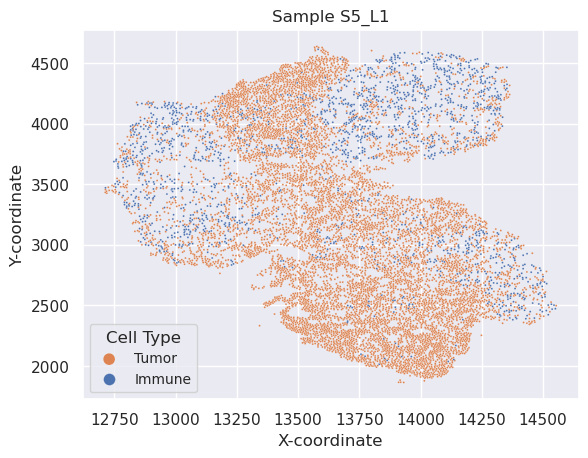

In [14]:
# Plotting
sample_df = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/data/P2_BTC/S5_L1.csv')
sns.set_theme(style='darkgrid')  # Set the aesthetic style of the plots
sns.scatterplot(data=sample_df, x='x_centroid', y='y_centroid', s=2, hue='tumor_immune')  # Plot points
plt.legend(title='Cell Type', labels=['Tumor', 'Immune'], loc='lower left', fontsize=10, markerscale=6)
plt.xlabel('X-coordinate')  # Optional: Set the x-axis label
plt.ylabel('Y-coordinate')  # Optional: Set the y-axis label
plt.title('Sample S5_L1')  # Optional: Set the plot title
plt.savefig('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/figures/original_scatter/s5_l1_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

Adjusted explanation value range: -0.01662003886377387 to 0.2703456859401822


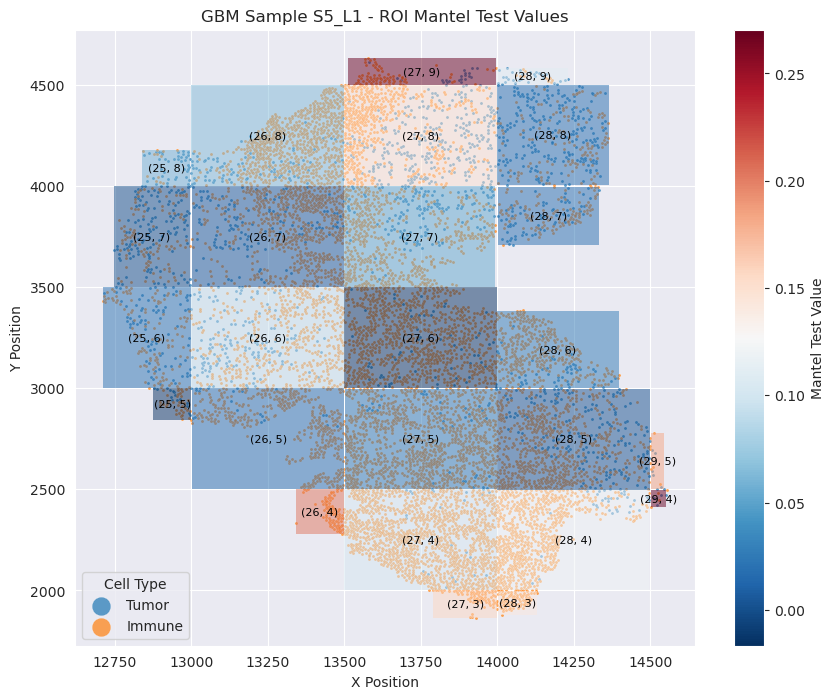

In [6]:
# Plot Heatmap with Explainer Values

# Define custom legend and scatter plot options
legend_options = {
    'title': 'Cell Type',
    'markerscale': 6,
    'loc': 'lower left',
    'fontsize': 10
}

scatter_options = {
    's': 5,
    'zorder': 2,
    'alpha': 0.7  # Additional scatter plot options
}

# Call the function with custom options
plot_roi_explanations(
    data_dict=mantel_dict,
    sample_df=sample_df,
    bboxes=bboxes,
    legend_kwargs=legend_options,
    scatter_kwargs=scatter_options,
    title='GBM Sample S5_L1 - ROI Mantel Test Values',
    save_path='/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/figures/heatmaps/s5_l1_smallroi_cell_positions_with_mantel_values.png',
    dpi=300,
    bbox_inches='tight',
    cmap=cm.RdBu_r
)


In [87]:
immune_cell_count = cell_count_dict[1]   
tumor_cell_count = cell_count_dict[0]
# Calculate the weighted statistic
weighted_statistic = compute_weighted_statistic(statistics=mantel_dict.values(),
                                                  cell_counts_type_A=immune_cell_count,
                                                  cell_counts_type_B=tumor_cell_count)

print(weighted_statistic)

0.06324290903302555


### Combining Result DataFrames and Plotting

In [6]:
# Load CSV files, ignoring the index column
infidelity_results = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/gd_results/gd_infidelity_results.csv', index_col=0)
max_sens_results = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/gd_results/gd_max_sens_results.csv', index_col=0)

# Merge the two dataframes on sample_name
# combined_results = pd.merge(infidelity_results, 
#                             max_sens_results[['sample_name', 'max_sens']], 
#                             on='sample_name',
#                             how='inner')

In [20]:
save_dir = '/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/gd_results/heatmaps'
#Create heatmap of results
plt.figure(figsize=(5,10))
results_df = pd.DataFrame(infidelity_results).set_index('sample_name')

# Log transform the data
results_df = -1 * np.log10(results_df)

# Get actual min/max values from data for better color scaling
vmin = results_df.min().min()  # Get minimum value across all data
vmax = results_df.max().max()  # Get maximum value across all data

# Create heatmap with dynamic scale based on data range
sns.heatmap(results_df, cmap='Blues', annot=True, fmt='.2f',
            vmin=vmin, vmax=vmax,  # Use data-driven min/max values
            center=(vmax+vmin)/2)  # Center the colormap on the data

plt.xlabel('Evaluation Metric')
plt.ylabel('Sample')
plt.title('Geographic Diversity Infidelity (Log Scale)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'gd_infidelity_heatmap.png'))
plt.close() 

In [21]:
save_dir = '/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/gd_results/heatmaps'
#Create heatmap of results
plt.figure(figsize=(5, 10))
results_df = pd.DataFrame(max_sens_results).set_index('sample_name')

# Log transform the data
results_df = -1 * np.log(results_df)

# Get actual min/max values from data for better color scaling
vmin = results_df.min().min()  # Get minimum value across all data
vmax = results_df.max().max()  # Get maximum value across all data

# Create heatmap with dynamic scale based on data range
sns.heatmap(results_df, cmap='Blues', annot=True, fmt='.2f',
            vmin=vmin, vmax=vmax,  # Use data-driven min/max values
            center=(vmax+vmin)/2)  # Center the colormap on the data

plt.xlabel('Evaluation Metric')
plt.ylabel('Sample')
plt.title('Geographic Diversity Maximum Sensitivity (Log Scale)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'gd_max_sens_heatmap.png'))
plt.close() 